In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Load datasets
elevation_df = pd.read_excel("Elevation.xlsx")
flood_df = pd.read_excel("Flood.xlsx")
rainfall_df = pd.read_excel("RainFall.xlsx")
river_discharge_df = pd.read_excel("River_Discharge.xlsx")

In [ ]:
# Convert date columns to datetime
flood_df["Date"] = pd.to_datetime(flood_df["Date"])
rainfall_df["Date"] = pd.to_datetime(rainfall_df["Date"])

In [ ]:
# Melt river discharge data into long format
river_discharge_long = river_discharge_df.melt(
    id_vars=["Kecamatan"],
    var_name="Date",
    value_name="River_Discharge"
)
river_discharge_long["Date"] = pd.to_datetime(river_discharge_long["Date"])

In [ ]:
# Merge flood and rainfall data
flood_rain_merged = pd.merge(
    flood_df, rainfall_df,
    on=["Kecamatan", "Date"],
    how="outer"
)

# Merge with river discharge data
combined = pd.merge(
    flood_rain_merged, river_discharge_long,
    on=["Kecamatan", "Date"],
    how="outer"
)

# Merge with elevation data (static)
merged = pd.merge(
    combined, elevation_df,
    on="Kecamatan",
    how="left"
)

# # Optional: Drop unnecessary columns if desired
# merged.drop(columns=["Kecamatan_ID", "Id"], inplace=True, errors="ignore")

In [ ]:
merged.describe()
merged.head(50)

,Kecamatan_ID,Kecamatan,Date,Flood,Id,RainFall,River_Discharge,Elevation
0,0,BANGKA,2023-11-14,1,24,8.6,11.27,26
1,0,BANGKA,2023-11-15,0,24,0.5,26.23,26
2,0,BANGKA,2023-11-16,0,24,0.0,18.10,26
3,0,BANGKA,2023-11-17,0,24,0.0,24.76,26
4,0,BANGKA,2023-11-18,0,24,3.3,17.20,26
5,0,BANGKA,2023-11-19,0,24,0.0,12.77,26
6,0,BANGKA,2023-11-20,0,24,0.0,12.55,26
7,1,BIDARA CINA,2023-11-14,1,5,6.5,11.27,22
8,1,BIDARA CINA,2023-11-15,0,5,0.8,26.23,22
9,1,BIDARA CINA,2023-11-16,0,5,0.0,18.10,22


In [ ]:
# Handle missing values
merged = merged.dropna()

In [ ]:
# Select features and target
features = ['RainFall', 'River_Discharge', 'Elevation']
X = merged[features]
y = merged['Flood']

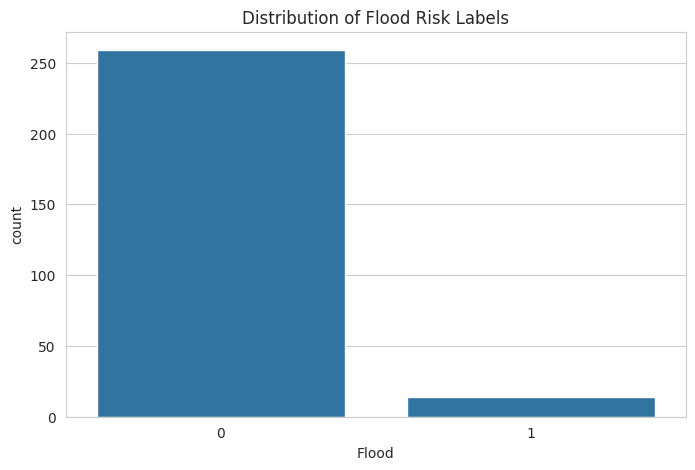

In [ ]:
# Distribution of flood risk
plt.figure(figsize=(8,5))
sns.countplot(x='Flood', data=merged)
plt.title('Distribution of Flood Risk Labels')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Assuming:
# X = your original features (before scaling)
# y = your target ('flood_risk')

# 1. Split into train-test FIRST (before any resampling/scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # No stratification
)

# 2. Scale the data (fit ONLY on training data to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use same scaler on test

# 3. Apply SMOTE ONLY to the training data
smote = SMOTE(random_state=42, k_neighbors=5)  # Lower than default (k=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Now you have:
# - Balanced training set (X_train_res, y_train_res)
# - Original test set (X_test_scaled, y_test) - untouched by SMOTE

import numpy as np
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [180  11]
After SMOTE: [180 180]


<ipython-input-222-639890209>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Flood', data=merged, palette="viridis")


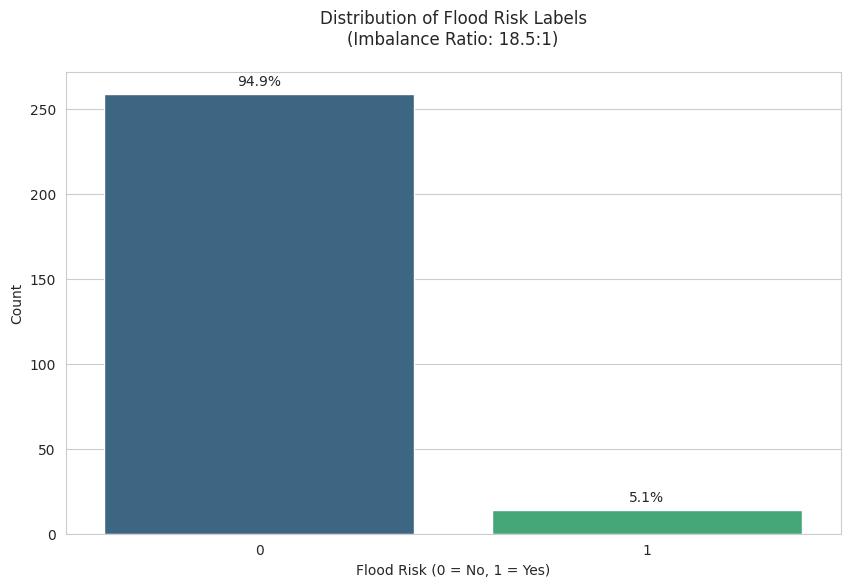

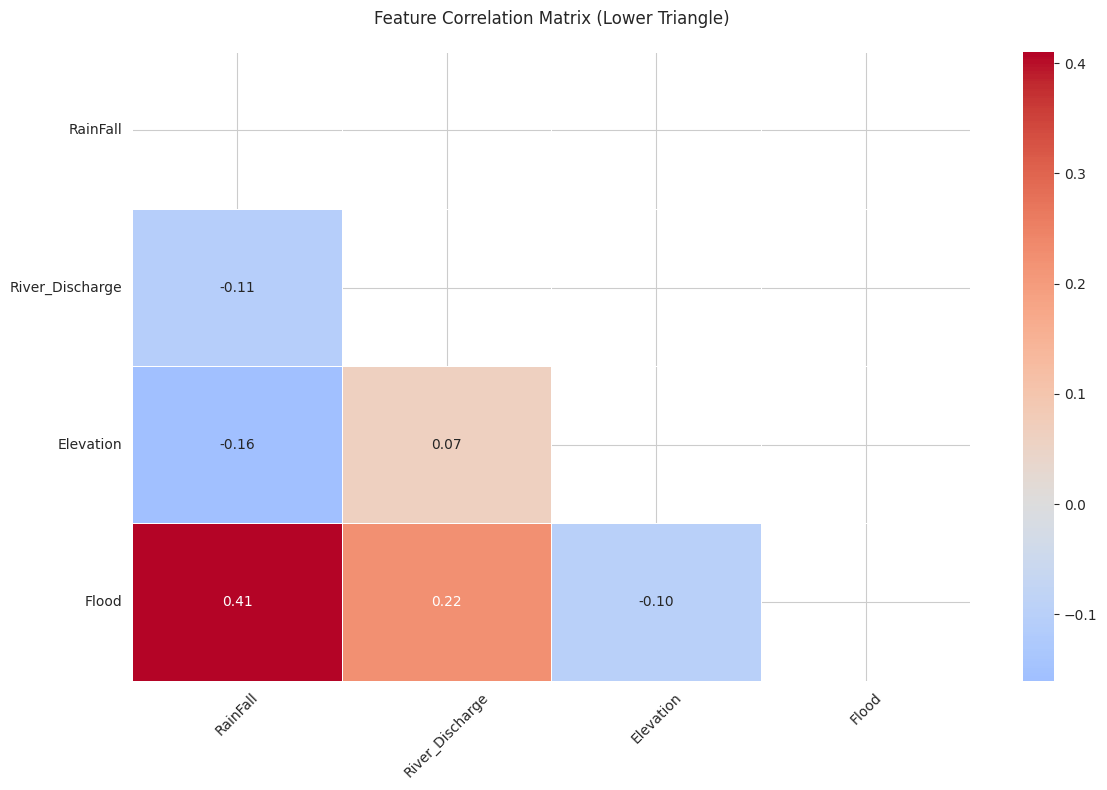

<ipython-input-222-639890209>:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Flood', y=feature, data=merged, palette="Set2")
<ipython-input-222-639890209>:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Flood', y=feature, data=merged, palette="Set2")
<ipython-input-222-639890209>:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Flood', y=feature, data=merged, palette="Set2")


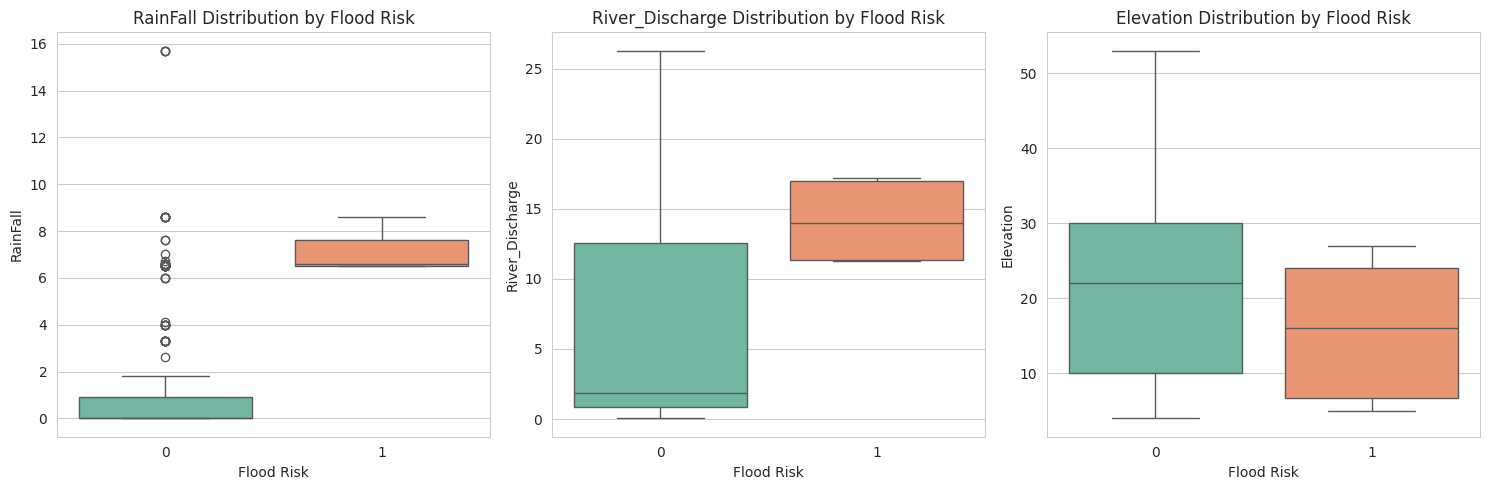


Statistical Summary by Flood Risk Status:
Flood                           0          1
RainFall        count  259.000000  14.000000
                mean     1.428571   7.057143
                std      2.832240   0.791021
                min      0.000000   6.500000
                25%      0.000000   6.500000
                50%      0.000000   6.600000
                75%      0.900000   7.600000
                max     15.700000   8.600000
River_Discharge count  259.000000  14.000000
                mean     6.296718  14.367857
                std      8.028816   2.656015
                min      0.050000  11.270000
                25%      0.870000  11.327500
                50%      1.860000  14.000000
                75%     12.550000  16.990000
                max     26.290000  17.200000
Elevation       count  259.000000  14.000000
                mean    21.926641  15.857143
                std     13.536572   9.272433
                min      4.000000   5.000000
            

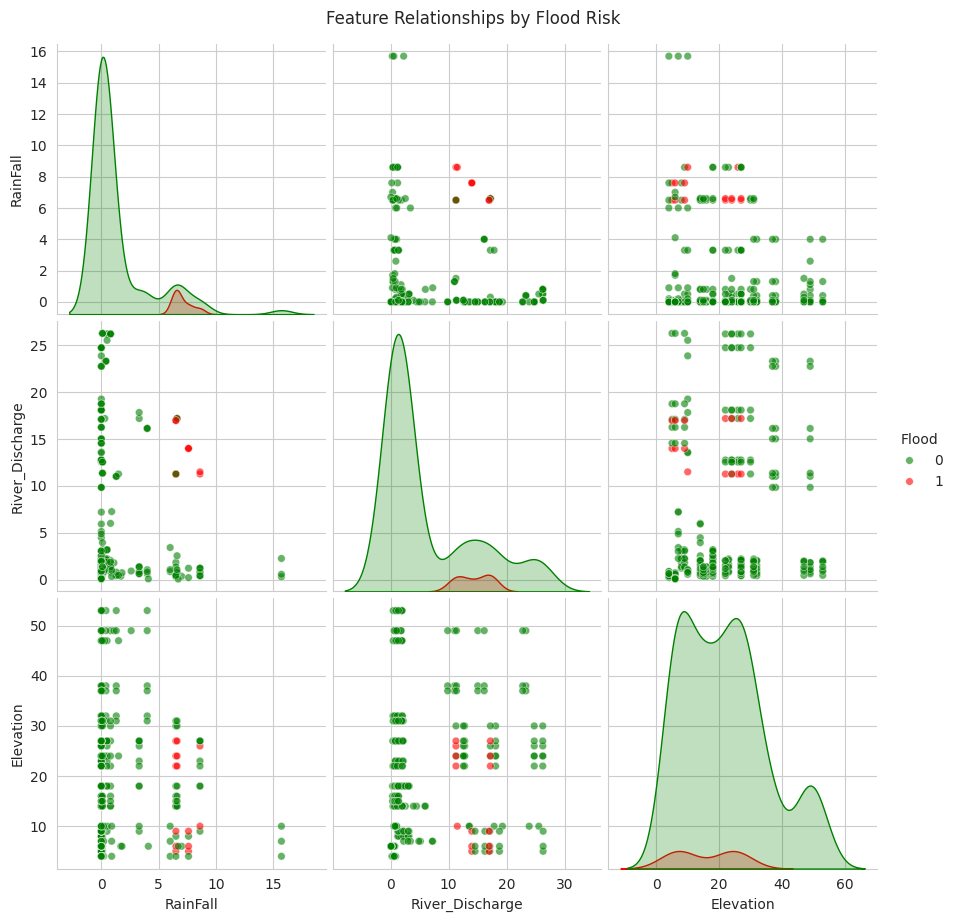

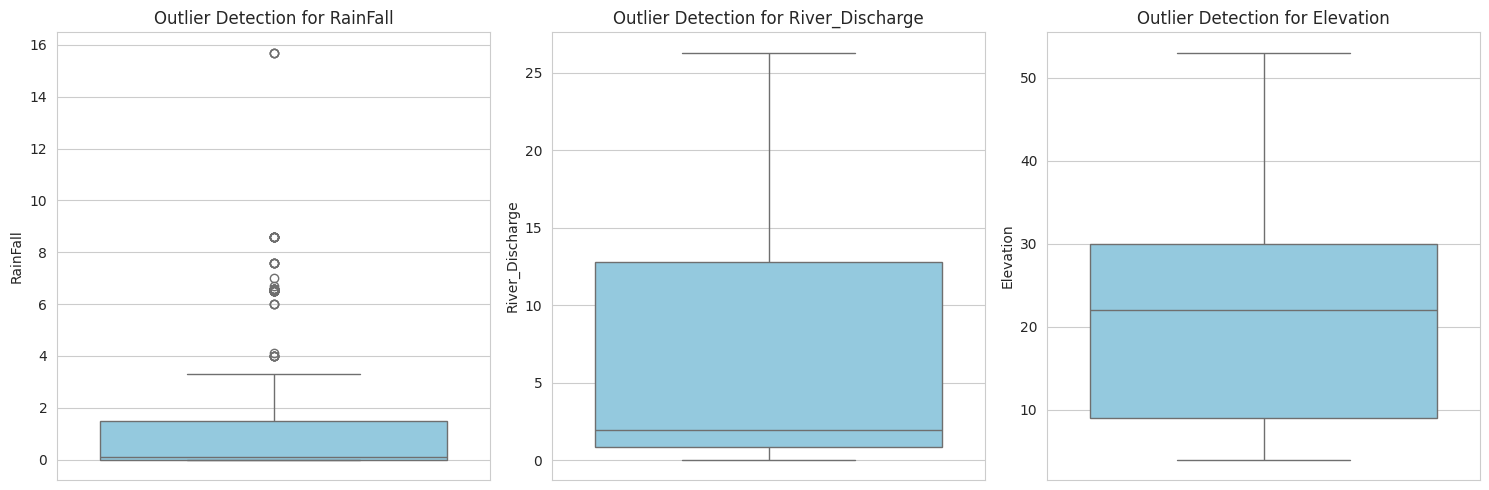

<ipython-input-222-639890209>:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Date', y=feature, hue='Flood', data=merged,
<ipython-input-222-639890209>:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Date', y=feature, hue='Flood', data=merged,
<ipython-input-222-639890209>:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Date', y=feature, hue='Flood', data=merged,


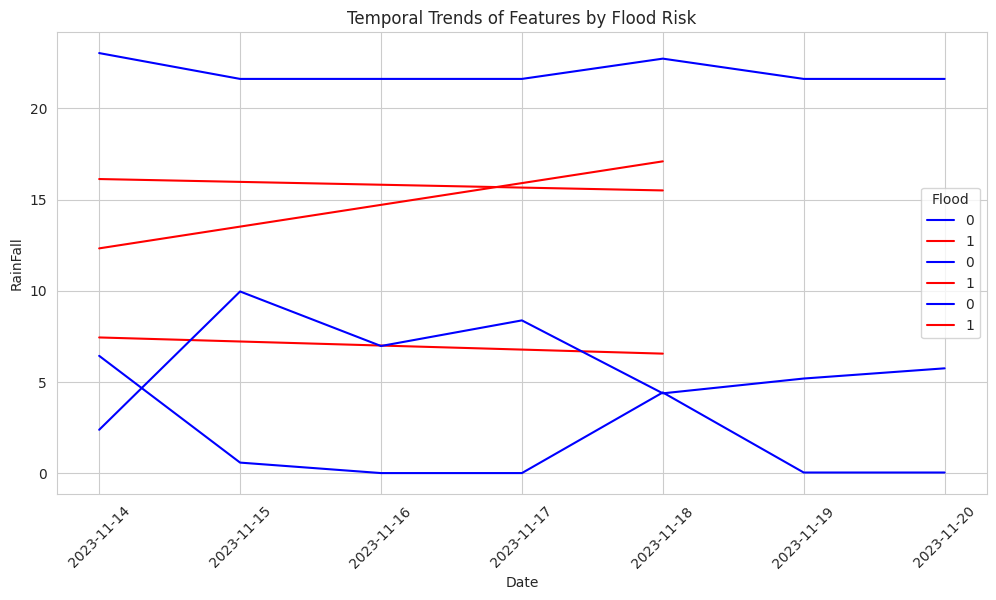

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Distribution of Flood Risk (Enhanced)
plt.figure(figsize=(10,6))
ax = sns.countplot(x='Flood', data=merged, palette="viridis")

# Add percentages
total = len(merged)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width()/2
    y = p.get_height() + 5
    ax.annotate(percentage, (x, y), ha='center')

plt.title('Distribution of Flood Risk Labels\n(Imbalance Ratio: {:.1f}:1)'.format(
    merged['Flood'].value_counts()[0]/merged['Flood'].value_counts()[1]), pad=20)
plt.xlabel('Flood Risk (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# 2. Correlation Analysis (Enhanced)
corr_matrix = merged[features + ['Flood']].corr()

plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            mask=mask, fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Matrix (Lower Triangle)', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Numerical Features Distribution by Flood Risk
num_features = ['RainFall', 'River_Discharge', 'Elevation']

plt.figure(figsize=(15,5))
for i, feature in enumerate(num_features, 1):
    plt.subplot(1, len(num_features), i)
    sns.boxplot(x='Flood', y=feature, data=merged, palette="Set2")
    plt.title(f'{feature} Distribution by Flood Risk')
    plt.xlabel('Flood Risk')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# 4. Statistical Summary by Flood Risk
print("\nStatistical Summary by Flood Risk Status:")
print(merged.groupby('Flood')[num_features].describe().T)

# 5. Hypothesis Testing (t-tests)
print("\nHypothesis Testing (t-tests for mean differences):")
for feature in num_features:
    group0 = merged[merged['Flood'] == 0][feature]
    group1 = merged[merged['Flood'] == 1][feature]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    print(f"{feature}: t-stat = {t_stat:.3f}, p-value = {p_val:.4f}")

# 6. Pairplot with Flood Risk Highlight
sns.pairplot(merged, vars=num_features, hue='Flood',
             palette={0:"green", 1:"red"}, diag_kind='kde',
             plot_kws={'alpha':0.6, 's':30}, height=3)
plt.suptitle('Feature Relationships by Flood Risk', y=1.02)
plt.show()

# 7. Outlier Detection
plt.figure(figsize=(15,5))
for i, feature in enumerate(num_features, 1):
    plt.subplot(1, len(num_features), i)
    sns.boxplot(data=merged[feature], color="skyblue")
    plt.title(f'Outlier Detection for {feature}')
plt.tight_layout()
plt.show()

# 8. Time Series Analysis (if date/time column exists)
if 'Date' in merged.columns:
    merged['Date'] = pd.to_datetime(merged['Date'])
    plt.figure(figsize=(12,6))
    for feature in num_features:
        sns.lineplot(x='Date', y=feature, hue='Flood', data=merged,
                     palette={0:"blue", 1:"red"}, ci=None)
    plt.title('Temporal Trends of Features by Flood Risk')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
print("Class distribution in y_train:")
print(pd.Series(y_train).value_counts())

Class distribution in y_train:
Flood
0    180
1     11
Name: count, dtype: int64



Confusion Matrix - Random Forest (SMOTE)
                 Predicted Negative  Predicted Positive
Actual Negative                  79                   0
Actual Positive                   0                   3


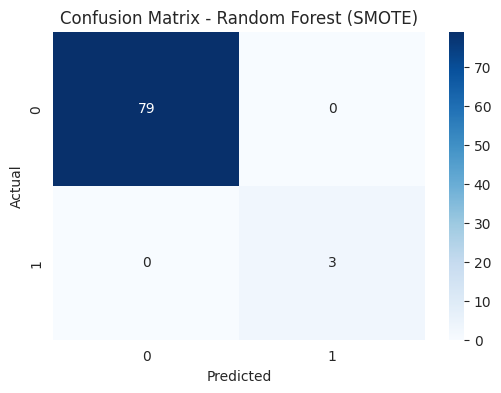


Confusion Matrix - Decision Tree (SMOTE)
                 Predicted Negative  Predicted Positive
Actual Negative                  79                   0
Actual Positive                   0                   3


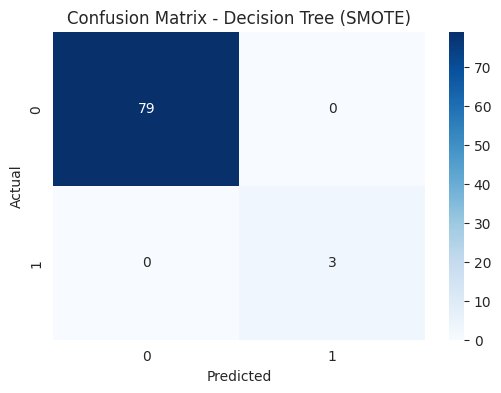


Confusion Matrix - Logistic Regression (SMOTE)
                 Predicted Negative  Predicted Positive
Actual Negative                  77                   2
Actual Positive                   0                   3


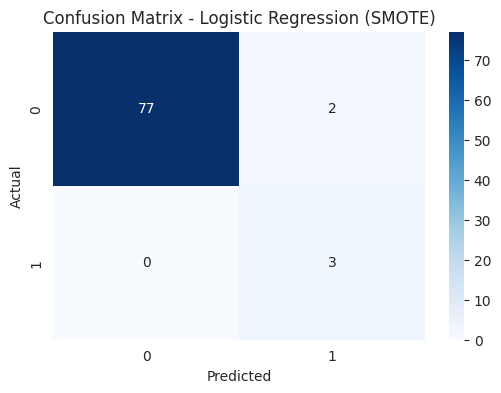


Confusion Matrix - KNN (SMOTE)
                 Predicted Negative  Predicted Positive
Actual Negative                  79                   0
Actual Positive                   0                   3


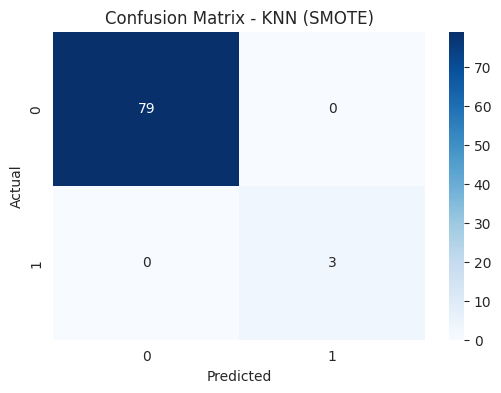

                 Model  Accuracy  Precision   Recall  F1-Score   ROC-AUC  \
0        Random Forest   1.00000   1.000000  1.00000  1.000000  1.000000   
1        Decision Tree   1.00000   1.000000  1.00000  1.000000  1.000000   
2  Logistic Regression   0.97561   0.985366  0.97561  0.978502  0.987342   
3                  KNN   1.00000   1.000000  1.00000  1.000000  1.000000   

       Log Loss  
0  1.014719e-02  
1  2.220446e-16  
2  1.605929e-01  
3  2.220446e-16  


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
}


results = []
for name, model in models.items():
    # Fit model on RESAMPLED data
    model.fit(X_train_res, y_train_res)

    # Predictions on original (unmodified) test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # For ROC-AUC

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC (binary classification)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except:
        roc_auc = "Not applicable"

    # Log Loss (if predict_proba exists)
    try:
        logloss = log_loss(y_test, y_pred_proba)
    except:
        logloss = "Not available"

    # Classification Report & Confusion Matrix
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Print confusion matrix with labels
    print(f"\nConfusion Matrix - {name} (SMOTE)")
    cm_df = pd.DataFrame(cm,
                        index=['Actual Negative', 'Actual Positive'],
                        columns=['Predicted Negative', 'Predicted Positive'])
    print(cm_df)

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Log Loss': logloss,
        'Classification Report': report,
        'Confusion Matrix': cm,
    })

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (SMOTE)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df.drop(['Classification Report', 'Confusion Matrix'], axis=1, inplace=True)
print(results_df)



Model Performance Comparison:
                 Model  Accuracy
0        Random Forest   1.00000
1        Decision Tree   1.00000
2  Logistic Regression   0.97561
3                  KNN   1.00000


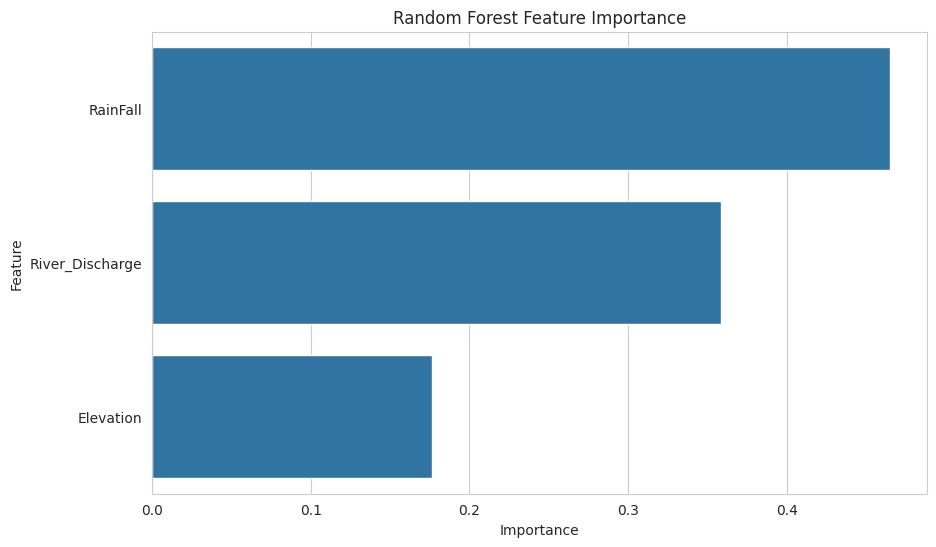

In [ ]:
# Display results
results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df[['Model', 'Accuracy']])

# Feature importance for Random Forest
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title('Random Forest Feature Importance')
plt.show()